<div style="border-radius: 15px; border: 3px solid indigo; padding: 15px;">
<b> Комментарий ревьюера</b>
    
    
Привет! Меня зовут Даниил Вяжев, я буду проверять твой проект. Если не против, давай общаться на «ты». Если тебе такой стиль общения не нравится, напиши об этом, будем на «вы».

Сразу хочу обратить внимание на цветовую разметку:

<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">

Зеленым с пометкой ✔️ отмечены отличные решения и идеи, которые можно и нужно использовать в будущем.
</div>
    
<div class="alert alert-warning" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">

Желтым с пометкой ⚠️ отмечено то, что можно или нужно оптимизировать, в зависимости от контекста.</div>    
    
<div class="alert alert-danger" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">

Красным с пометкой ❌ обозначены пропущенные пункты задания и ошибки, которые обязательно надо будет исправить, чтобы результаты были верные.</div> 
    
**Ответы на мои комментарии или доработки по моим рекомендациям попрошу выделить каким-нибудь цветом, кроме перечисленных.**
Также я попрошу тебя **не менять, не передвигать и не удалять мои комментарии**, чтобы при последующей проверке мне было проще ориентироваться.
        
<hr>
    
<font color= 'dodgerblue'>**По проекту:**</font> 
    
    
Код отлично структурирован, логика разделена на этапы, используются современные подходы (pathlib, разреженные матрицы, параллельные вычисления с tqdm), функции для EDA и метрик универсальные и аккуратные. Радует внимание к целостности данных - ты не только проверяешь, но и чистишь битые ссылки, сохраняя консистентность. Реализованы три разных подхода к рекомендациям (популярные, ALS, контентные), и ты даже пробуешь объединить их ранжирующей моделью. 
    
Моменты, которые стоит доработать: дублирование кодирования в ALS, смешение типов дат, маленкий объём данных для обучения CatBoost. Рекомендую в следующей итерации уделить внимание чистке предупреждений, унификации работы с датами и добавтьь текстовые выводы после каждого этапа (как ты сам отметил).
    
Мог бы принять проект, но если хочешь еще его докрутить, отправляю на доработку!
    
<hr style="border-top: 3px solid purple; "></hr>
Комментарии можешь оставлять с помощью такого кода в Markdown ячейке:
    
    
    <div class="alert alert-info">
    <h2> Комментарий студента</h2>


    Тут текст.
    </div>
    
    
    <font color='red'> Этот код позволяет менять цвет текста. </font>     


  

О том, как **форматировать текст** в Markdown ячейке или как добавлять ссылки, ты можешь узнать [тут](https://sqlbak.com/blog/jupyter-notebook-markdown-cheatsheet) и [вот тут](https://medium.com/analytics-vidhya/the-ultimate-markdown-guide-for-jupyter-notebook-d5e5abf728fd).




Желаю удачи!


<img src="https://user-images.githubusercontent.com/74038190/225813708-98b745f2-7d22-48cf-9150-083f1b00d6c9.gif" width="500">
</div>    



<div class="alert alert-info">
<h2> Комментарий студента</h2>


Привет, спасибо за проверку. Отправляю работу для защиты. Вижу, что замечания не критические, поэтому чтобы время не тратить оставлю так и на 2 этап перехожу. В рамках него прогоню ноутбук второй раз, уже исправленный.
</div>


<font color='red'> Этот код позволяет менять цвет текста. </font>    

**Инициализация**

Загружаем библиотеки необходимые для выполнения кода ноутбука.

Привет, отправляю работу на проверку. 

Для выполнения задания брал подмножество данных, чтобы ноут отработал, иначе падает(
Также в проекте пока нет выводов, добавлю во вторую итерацию.
Возможно в места код немного усложнен, заранее извиняюсь. Если что пиши, во 2 версии постараюсь исправить.

Заранее спасибо!

In [1]:
import os
import pickle
from pathlib import Path

import boto3
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import scipy.sparse
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from implicit.als import AlternatingLeastSquares
import sklearn.metrics
from catboost import CatBoostClassifier, Pool
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("data")
TRACKS_PATH = DATA_DIR / "tracks.parquet"
CATALOG_NAMES_PATH = DATA_DIR / "catalog_names.parquet"
INTERACTIONS_PATH = DATA_DIR / "interactions.parquet"

OUTPUT_DIR = Path("recsys/data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RECOMMENDATIONS_DIR = Path("recsys/recommendations")
RECOMMENDATIONS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DEBUG = False
DEBUG_ROWS_SUBSET = 50_000
PROD_ROWS_SUBSET = 2_500_000

c:\Users\Selecty\anaconda3\envs\recsys\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Хорошо.

### **=== ЭТАП 1 ===**

**Загрузка первичных данных**

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [2]:
tracks = pd.read_parquet(TRACKS_PATH)
catalog_names = pd.read_parquet(CATALOG_NAMES_PATH)
interactions = pd.read_parquet(INTERACTIONS_PATH)

# Subset data
rows_limit = DEBUG_ROWS_SUBSET if DEBUG else PROD_ROWS_SUBSET
interactions = interactions.sample(
    n=min(rows_limit, len(interactions)), random_state=RANDOM_STATE
)
track_ids = interactions["track_id"].unique()
tracks = tracks[tracks["track_id"].isin(interactions["track_id"])]
catalog_by_type = {
    t: catalog_names[catalog_names["type"] == t]
    for t in ["album", "artist", "genre"]
}
catalog_by_type["track"] = catalog_names[catalog_names["type"] == "track"]


exploded_by_col = {}
n_broken_by_col = {}
for ref_type, col in [
    ("artist", "artists"),
    ("album", "albums"),
    ("genre", "genres"),
]:
    exploded = (
        tracks[["track_id", col]]
        .explode(col)
        .dropna(subset=[col])
    )
    exploded[col] = pd.to_numeric(exploded[col], errors="coerce")
    exploded = exploded.dropna(subset=[col])
    exploded[col] = exploded[col].astype("int64")
    catalog_type = catalog_names.loc[
        catalog_names["type"] == ref_type, ["id", "name"]
    ]
    merged = exploded.merge(catalog_type, left_on=col, right_on="id", how="left")
    n_broken_by_col[col] = merged["name"].isna().sum()
    valid = merged.dropna(subset=["name"])[["track_id", col]]
    exploded_by_col[col] = valid
    valid_ids = valid[col].unique()
    catalog_by_type[ref_type] = catalog_by_type[ref_type][
        catalog_by_type[ref_type]["id"].isin(valid_ids)
    ]
    # Drop broken links from tracks
    valid_set = set(valid_ids)
    tracks[col] = tracks[col].apply(
        lambda lst: [x for x in (lst or []) if x in valid_set] if isinstance(lst, list) else lst
    )

catalog_by_type["track"] = catalog_by_type["track"][
    catalog_by_type["track"]["id"].isin(track_ids)
]
catalog_names = pd.concat(catalog_by_type.values(), ignore_index=True)

# --- Prebuilt lookups (reused in EDA and data transformation) ---
track_names = (
    catalog_by_type["track"][["id", "name"]]
    .rename(columns={"id": "track_id", "name": "track_name"})
)
track_name_map = track_names.set_index("track_id")["track_name"].to_dict()
listened_track_ids = set(track_ids)
all_track_ids = set(tracks["track_id"].unique())

print(
    f"Subset: interactions={len(interactions)}, tracks={len(tracks)}, catalog_names={len(catalog_names)} (limit={rows_limit})"
)

print("tracks:", tracks.shape)
print("catalog_names:", catalog_names.shape)
print("interactions:", interactions.shape)

display(tracks.sample(5, random_state=RANDOM_STATE))
display(catalog_names.sample(5, random_state=RANDOM_STATE))
display(interactions.sample(5, random_state=RANDOM_STATE))

Subset: interactions=2500000, tracks=343781, catalog_names=749182 (limit=2500000)
tracks: (343781, 4)
catalog_names: (749182, 3)
interactions: (2500000, 4)


,track_id,albums,artists,genres
721565,53548207,[7660143],"[1426524, 37481, 10044710]","[44, 75]"
484756,33379187,[411771],[412462],"[19, 325, 61]"
319590,20713806,[2362871],[188978],"[2, 102]"
578613,39855236,[5157474],[194360],[11]
84918,739666,[82155],[219149],"[23, 69]"


,id,type,name
209649,7407279,album,Ballerina
9940,45679,album,The Best Of Benny Goodman
736494,88404627,track,HADABA
454310,2642353,track,Flight B
663384,57686610,track,What’s My Name


,user_id,track_id,track_seq,started_at
60,330588,347957,61,2022-07-04
86,400624,42556936,87,2022-12-24
1029,962816,28211811,1030,2022-04-06
267,481472,37258106,268,2022-11-08
355,133337,953445,356,2022-07-04


### **Обзор данных**

Проверяем данные, есть ли с ними явные проблемы.

In [3]:
# Базовый обзор: типы, пропуски, уникальные значения
def df_overview(df: pd.DataFrame, name: str, id_cols=None):
    print(f"=== {name} ===")
    df.info()
    print()
    print("shape:", df.shape)
    print()
    na = df.isna().mean().sort_values(ascending=False)
    print("NA share (top-20):")
    display(na.head(20))
    if id_cols:
        n_combo = df[id_cols].drop_duplicates().shape[0]
        print(f"nunique({id_cols}) = {n_combo}")
    print()

df_overview(tracks, "tracks", id_cols=["track_id"])
df_overview(catalog_names, "catalog_names", id_cols=["id", "type"])
df_overview(interactions, "interactions", id_cols=["user_id", "track_id"])


=== tracks ===
<class 'pandas.core.frame.DataFrame'>
Index: 343781 entries, 4 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   track_id  343781 non-null  int64 
 1   albums    343781 non-null  object
 2   artists   343781 non-null  object
 3   genres    343781 non-null  object
dtypes: int64(1), object(3)
memory usage: 13.1+ MB

shape: (343781, 4)

NA share (top-20):


track_id    0.0
albums      0.0
artists     0.0
genres      0.0
dtype: float64

nunique(['track_id']) = 343781

=== catalog_names ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 749182 entries, 0 to 749181
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      749182 non-null  int64 
 1   type    749182 non-null  object
 2   name    749182 non-null  object
dtypes: int64(1), object(2)
memory usage: 17.1+ MB

shape: (749182, 3)

NA share (top-20):


id      0.0
type    0.0
name    0.0
dtype: float64

nunique(['id', 'type']) = 749182

=== interactions ===
<class 'pandas.core.frame.DataFrame'>
Index: 2500000 entries, 130 to 155
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 62.0 MB

shape: (2500000, 4)

NA share (top-20):


user_id       0.0
track_id      0.0
track_seq     0.0
started_at    0.0
dtype: float64

nunique(['user_id', 'track_id']) = 2500000



<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Лаконичная и информативная функция. Хорошо!

**Проверка связей между таблицами и диапазон дат**

Проверяем «битые» ссылки (interactions → tracks, tracks → catalog_names) и диапазон дат в `interactions.started_at`.

In [4]:
# 1) Broken links: interactions -> tracks (left join, count NaN)
merged_inter = interactions.merge(
    tracks[["track_id"]].assign(_linked=1), on="track_id", how="left"
)
n_inter_broken = merged_inter["_linked"].isna().sum()
print(
    "Interactions with track_id not in tracks (join):",
    n_inter_broken,
    f"({n_inter_broken/len(interactions):.4%})",
)

# 2) Broken links: tracks -> catalog_names
for ref_type, col in [("artist", "artists"), ("album", "albums"), ("genre", "genres")]:
    if col in n_broken_by_col:
        print(
            f"Tracks {col} ids not in catalog_names (type={ref_type}, join):",
            f"{n_broken_by_col[col]} rows",
        )

# 3) Date range for interactions.started_at (already datetime)
if "started_at" in interactions.columns:
    started = interactions["started_at"]
    print(
        "interactions.started_at range:",
        started.min(),
        "->",
        started.max(),
    )
    print(
        "started_at NA count:",
        started.isna().sum(),
        f"({started.isna().mean():.4%})",
    )

Interactions with track_id not in tracks (join): 0 (0.0000%)
Tracks artists ids not in catalog_names (type=artist, join): 0 rows
Tracks albums ids not in catalog_names (type=album, join): 0 rows
Tracks genres ids not in catalog_names (type=genre, join): 16134 rows
interactions.started_at range: 2022-01-01 00:00:00 -> 2022-12-31 00:00:00
started_at NA count: 0 (0.0000%)


**Выводы**

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

### **=== ЭТАП 2 ===**

**EDA**

Распределение количества прослушанных треков.

count    713071.000000
mean          3.505962
std           5.243088
min           1.000000
50%           2.000000
90%           8.000000
95%          12.000000
99%          25.000000
max         175.000000
Name: n_events, dtype: float64

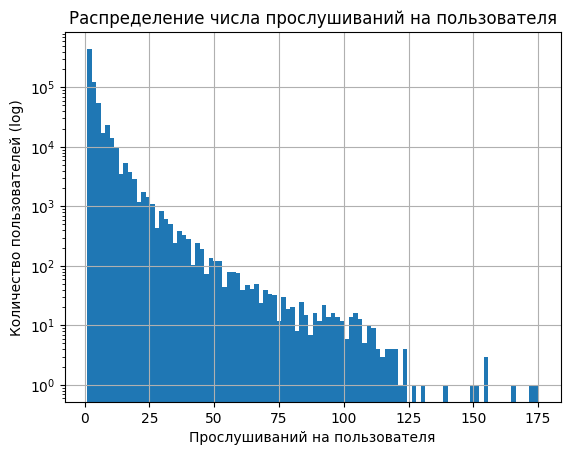

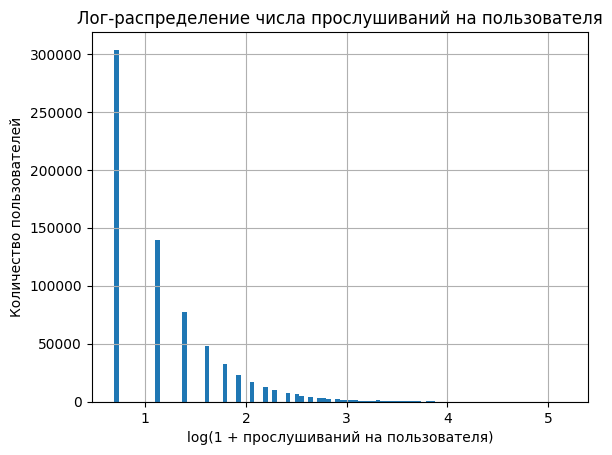

In [5]:
# Распределение количества прослушиваний (интеракций) на пользователя
user_cnt = (
    interactions.groupby("user_id")["track_id"].size().rename("n_events")
)
display(user_cnt.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure()
user_cnt.hist(bins=100)
plt.yscale("log")
plt.xlabel("Прослушиваний на пользователя")
plt.ylabel("Количество пользователей (log)")
plt.title("Распределение числа прослушиваний на пользователя")
plt.show()

plt.figure()
np.log1p(user_cnt).hist(bins=100)
plt.xlabel("log(1 + прослушиваний на пользователя)")
plt.ylabel("Количество пользователей")
plt.title("Лог-распределение числа прослушиваний на пользователя")
plt.show()


Наиболее популярные треки

In [6]:
def top_by_events(
    interactions,
    catalog_names,
    *,
    item_col,
    catalog_type,
    explode_col=None,
    exploded_by_col=None,
    name_col=None,
    top_k=20,
    top_pct=0.01,
):
    """
    Топ сущностей по числу событий.
    """
    if explode_col is None:
        count_series = (
            interactions.groupby(item_col).size().sort_values(ascending=False)
        )
        group_col = item_col
    else:
        exploded = interactions.merge(
            exploded_by_col[explode_col], on="track_id", how="left"
        ).dropna(subset=[explode_col])
        count_series = (
            exploded.groupby(explode_col).size().sort_values(ascending=False)
        )
        group_col = explode_col

    top = count_series.head(top_k).reset_index()
    top.columns = [group_col, "n_events"]

    catalog_ref = catalog_names.loc[
        catalog_names["type"] == catalog_type, ["id", "name"]
    ]
    top = top.merge(
        catalog_ref.rename(columns={"id": group_col}),
        on=group_col,
        how="left",
    )
    out_name = name_col if name_col else f"{catalog_type}_name"
    top = top.rename(columns={"name": out_name})

    n_top = max(1, int(top_pct * len(count_series)))
    share = count_series.head(n_top).sum() / count_series.sum()
    return top, count_series, share


# Наиболее популярные треки
top_tracks, track_pop, share_top1pct = top_by_events(
    interactions,
    catalog_names,
    item_col="track_id",
    catalog_type="track",
    top_k=20,
    top_pct=0.01,
)
display(top_tracks)
print(f"Share of events covered by top 1% tracks: {share_top1pct:.2%}")

,track_id,n_events,track_name
0,33311009,1253,Believer
1,53404,1189,Smells Like Teen Spirit
2,178529,1115,Numb
3,35505245,1097,I Got Love
4,65851540,969,Юность
5,60292250,964,Blinding Lights
6,51241318,963,In The End
7,6705392,953,Seven Nation Army
8,24692821,952,Way Down We Go
9,37384,940,Zombie


Share of events covered by top 1% tracks: 27.63%


<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Верно.

Наиболее популярные жанры

In [7]:
top_genres, genre_pop, share_top1pct_genres = top_by_events(
    interactions,
    catalog_names,
    item_col="genres",
    catalog_type="genre",
    explode_col="genres",
    exploded_by_col=exploded_by_col,
    name_col="genre_name",
    top_k=20,
    top_pct=0.01,
)
display(top_genres)
print(
    f"Share of events covered by top 1% genres: {share_top1pct_genres:.2%}"
)


,genres,n_events,genre_name
0,11.0,624766,pop
1,75.0,424334,rap
2,102.0,349082,allrock
3,20.0,299255,ruspop
4,3.0,283816,rusrap
5,68.0,225326,electronics
6,16.0,183284,dance
7,2.0,147316,rusrock
8,14.0,143384,rock
9,47.0,139856,metal


Share of events covered by top 1% genres: 15.07%


Треки, которые никто не прослушал

In [8]:
never_listened = sorted(list(all_track_ids - listened_track_ids))

print(
    "Tracks never listened:",
    len(never_listened),
    f"({len(never_listened)/len(all_track_ids):.2%} of catalog tracks)",
)

display(
    pd.DataFrame({
        "track_id": never_listened[:20],
        "track_name": [track_name_map.get(t) for t in never_listened[:20]],
    })
)

Tracks never listened: 0 (0.00% of catalog tracks)


,track_id,track_name


### **Преобразование данных**

In [9]:
items = tracks.merge(track_names, on="track_id", how="left")

events = (
    interactions.sort_values(["user_id", "started_at"])
    .reset_index(drop=True)
)

# Label encoding for user_id and track_id (fit on full events for consistent indices)
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
user_encoder.fit(events["user_id"])
item_encoder.fit(events["track_id"])
events["user_id_enc"] = user_encoder.transform(events["user_id"])
events["track_id_enc"] = item_encoder.transform(events["track_id"])
items["track_id_enc"] = item_encoder.transform(items["track_id"])

print("items:", items.shape)
print("events:", events.shape)
display(items.head())
display(events.head())

items: (343781, 6)
events: (2500000, 6)


,track_id,albums,artists,genres,track_name,track_id_enc
0,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],Don't Upset The Rhythm (Go Baby Go),0
1,141,"[12, 214, 60093, 2490809, 10023160, 15635235, ...",[84],[11],Never Forget You,1
2,144,"[13, 99422]",[90],"[59, 102]",Leave Me,2
3,146,"[13, 99422]",[90],"[59, 102]",I'm Goin' Mad,3
4,147,"[13, 99422]",[90],"[59, 102]",Action,4


,user_id,track_id,track_seq,started_at,user_id_enc,track_id_enc
0,0,1750835,9,2022-07-30,0,41481
1,1,628687,5,2022-06-15,1,24644
2,3,27317251,6,2022-03-18,2,134383
3,4,27032384,117,2022-08-07,3,133094
4,9,56570805,10,2022-11-27,4,255066


### **Сохранение данных**

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [10]:
# Сохранение данных (локально) + (опционально) в S3
load_dotenv()
s3_bucket = os.environ.get("S3_BUCKET_NAME")
s3_access_key = os.environ.get("AWS_ACCESS_KEY_ID")
s3_secret_access_key = os.environ.get("AWS_SECRET_ACCESS_KEY")

items_out = OUTPUT_DIR / "items.parquet"
events_out = OUTPUT_DIR / "events.parquet"

items.to_parquet(items_out, index=False)
events.to_parquet(events_out, index=False)

encoders_path = OUTPUT_DIR / "encoders.pkl"
with open(encoders_path, "wb") as f:
    pickle.dump({"user_encoder": user_encoder, "item_encoder": item_encoder}, f)

print("Saved locally:")
print(" -", items_out.resolve())
print(" -", events_out.resolve())

# if s3_bucket and s3_access_key and s3_secret_access_key:
#     s3_prefix = "recsys/data"
#     client = boto3.client(
#         "s3",
#         aws_access_key_id=s3_access_key,
#         aws_secret_access_key=s3_secret_access_key,
#     )
#     client.upload_file(
#         str(items_out), s3_bucket, f"{s3_prefix}/items.parquet"
#     )
#     client.upload_file(
#         str(events_out), s3_bucket, f"{s3_prefix}/events.parquet"
#     )
#     print(f"Uploaded to s3://{s3_bucket}/{s3_prefix}/")
# else:
#     print(
#         "S3 creds not set (S3_BUCKET_NAME, AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY)"
#         " -> skip S3 upload"
#     )


Saved locally:
 - C:\Users\Selecty\Desktop\leroy\yandex-mle\mle-project-sprint-4-v001\recsys\data\items.parquet
 - C:\Users\Selecty\Desktop\leroy\yandex-mle\mle-project-sprint-4-v001\recsys\data\events.parquet


### **Очистка памяти**

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [11]:
# Очистка памяти: удаляем датафреймы этапов 1–2, данные для моделирования будут загружены из S3
del tracks, catalog_names, interactions, items, events
gc.collect()

24929

<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Принято, вопросов нет.

### **=== ЭТАП 3 ===**

**Загрузка данных**

Если необходимо, то загружаем items.parquet, events.parquet.

In [12]:
# Загрузка подготовленных данных
items_path = OUTPUT_DIR / "items.parquet"
events_path = OUTPUT_DIR / "events.parquet"

items = pd.read_parquet(items_path)
events = pd.read_parquet(events_path)

print("items:", items.shape)
print("events:", events.shape)
display(items.head())
display(events.head())


items: (343781, 6)
events: (2500000, 6)


,track_id,albums,artists,genres,track_name,track_id_enc
0,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],Don't Upset The Rhythm (Go Baby Go),0
1,141,"[12, 214, 60093, 2490809, 10023160, 15635235, ...",[84],[11],Never Forget You,1
2,144,"[13, 99422]",[90],"[59, 102]",Leave Me,2
3,146,"[13, 99422]",[90],"[59, 102]",I'm Goin' Mad,3
4,147,"[13, 99422]",[90],"[59, 102]",Action,4


,user_id,track_id,track_seq,started_at,user_id_enc,track_id_enc
0,0,1750835,9,2022-07-30,0,41481
1,1,628687,5,2022-06-15,1,24644
2,3,27317251,6,2022-03-18,2,134383
3,4,27032384,117,2022-08-07,3,133094
4,9,56570805,10,2022-11-27,4,255066


### **Разбиение данных**

Разбиваем данные на тренировочную, тестовую выборки.

In [13]:
SPLIT_DATE = "2022-12-16"
train_events = events[events["started_at"] < SPLIT_DATE]
test_events = events[events["started_at"] >= SPLIT_DATE]
train_user_ids_set = set(train_events["user_id"])
print("train_events:", train_events.shape)
print("test_events:", test_events.shape)

train_events: (2343730, 6)
test_events: (156270, 6)


<div class="alert alert-warning" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ⚠️</b>
    
Рекомендую привести все даты к единому типу, например pd.Timestamp.

### **RecSys**

### **Топ популярных**

Рассчитаем рекомендации как топ популярных.

In [35]:
# Top Popular: robust popularity = reach (users) × engagement (track_seq)
# lower seq = stronger signal
TOP_N = 10

# Per-user max track_seq so engagement is relative to each user's history (early vs late)
max_seq_per_user = (
    train_events.groupby("user_id")["track_seq"].transform("max").clip(lower=1)
)
_train = train_events.assign(
    engagement=1.0 / (1.0 + train_events["track_seq"] / max_seq_per_user)
)

item_popularity = (
    _train.groupby("track_id")
    .agg(users=("user_id", "nunique"), avg_engagement=("engagement", "mean"))
    .reset_index()
    .rename(columns={"track_id": "item_id"})
)

# Scale
scaler = MinMaxScaler()
item_popularity[["users_norm", "avg_engagement_norm"]] = scaler.fit_transform(
    item_popularity[["users", "avg_engagement"]]
)
item_popularity["popularity_score"] = (
    item_popularity["users_norm"] * item_popularity["avg_engagement_norm"]
)
item_popularity = item_popularity.sort_values("popularity_score", ascending=False)

item_popularity_top = item_popularity.head(TOP_N)[['item_id', 'popularity_score']].rename(
    columns={'popularity_score': 'score'}
).reset_index(drop=True)

item_popularity_top.to_parquet(RECOMMENDATIONS_DIR / "cold_recs.parquet", index=False)
print(f"Saved cold_recs to parquet: {len(item_popularity_top)} rows")

Saved cold_recs to parquet: 10 rows


In [36]:
# Display TOPN cold_start recs
top_items_with_name = item_popularity.merge(
    items[["track_id", "track_name"]].rename(columns={"track_id": "item_id"}),
    on="item_id",
    how="left",
)

top_items_with_name = top_items_with_name[
    ["item_id", "track_name", "users", "avg_engagement", "popularity_score"]
]

with pd.option_context("display.max_rows", 10):
    display(top_items_with_name.head(10))

,item_id,track_name,users,avg_engagement,popularity_score
0,53404,Smells Like Teen Spirit,1173,0.837832,0.672068
1,178529,Numb,1109,0.808789,0.580747
2,37384,Zombie,936,0.861644,0.573956
3,48951,It's My Life,814,0.838365,0.466941
4,148345,Californication,770,0.820211,0.417973
5,328683,Bring Me To Life,769,0.794956,0.384507
6,10216,Wind Of Change,557,0.892294,0.370230
7,52100,Don't Speak,662,0.824540,0.364128
8,137670,Gangsta's Paradise,651,0.827526,0.361364
9,178495,In the End,650,0.822581,0.355360


### **Персональные**

Рассчитаем персональные рекомендации.

In [37]:
# 3.2 Personal Recommendations (ALS)

# Prepare data for ALS: create user-item matrix
# Load encoders saved during data preparation (Stage 1)
encoders_path = OUTPUT_DIR / "encoders.pkl"
with open(encoders_path, "rb") as f:
    encoders = pickle.load(f)
user_encoder = encoders["user_encoder"]
item_encoder = encoders["item_encoder"]
unique_users = user_encoder.classes_
unique_items = item_encoder.classes_

# Add encoded columns for direct matrix construction
events_train = train_events
events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
events_train["item_id_enc"] = item_encoder.transform(events_train["track_id"])
events_train["rating"] = 1.0  # Binary implicit feedback

# Create CSR matrix directly
user_item_matrix = scipy.sparse.csr_matrix(
    (
        events_train["rating"].values,
        (events_train["user_id_enc"].values, events_train["item_id_enc"].values),
    ),
    shape=(len(unique_users), len(unique_items)),
    dtype=np.float32,
)

print(f"User-item matrix shape: {user_item_matrix.shape}")
print(f"Non-zero entries: {user_item_matrix.nnz}")

# Train ALS model
als_model = AlternatingLeastSquares(
    factors=50,
    regularization=0.1,
    iterations=15,
    random_state=RANDOM_STATE,
    num_threads=4
)

print("Training ALS model...")
als_model.fit(user_item_matrix)
print("ALS model trained successfully")

# Generate recommendations for train users (candidates for CatBoost ranker)
train_users_recommend = train_events["user_id"].unique()
user_ids_encoded = user_encoder.transform(train_users_recommend)

item_ids_enc, als_scores = als_model.recommend(
    user_ids_encoded,
    user_item_matrix[user_ids_encoded],
    filter_already_liked_items=True,
    N=TOP_N
)

# Convert to DataFrame
als_recommendations = pd.DataFrame({
    "user_id_enc": user_ids_encoded,
    "item_id_enc": [row.tolist() for row in item_ids_enc],
    "score": [row.tolist() for row in als_scores],
})
als_recommendations = als_recommendations.explode(
    ["item_id_enc", "score"], ignore_index=True)
als_recommendations["item_id_enc"] = als_recommendations["item_id_enc"].astype(np.int64)
als_recommendations["score"] = als_recommendations["score"].astype(np.float64)

# Map encoded IDs back to original IDs
als_recommendations["user_id"] = user_encoder.inverse_transform(
    als_recommendations["user_id_enc"])
als_recommendations["item_id"] = item_encoder.inverse_transform(
    als_recommendations["item_id_enc"])
als_recommendations = als_recommendations.drop(
    columns=["user_id_enc", "item_id_enc"])

# Add rank per user
als_recommendations["rank"] = als_recommendations.groupby("user_id").cumcount() + 1
personal_als = als_recommendations[["user_id", "item_id", "score", "rank"]].copy()
personal_als.to_parquet(RECOMMENDATIONS_DIR / "personal_als.parquet", index=False)
print(f"personal_als: {personal_als.shape}, saved to {RECOMMENDATIONS_DIR / 'personal_als.parquet'}")
display(personal_als.head(10))

User-item matrix shape: (713071, 343781)
Non-zero entries: 2343730
Training ALS model...


100%|██████████| 15/15 [00:11<00:00,  1.28it/s]


ALS model trained successfully
personal_als: (6736290, 4), saved to recsys\recommendations\personal_als.parquet


,user_id,item_id,score,rank
0,0,178529,1.402180e-12,1
1,0,44184116,9.735572e-13,2
2,0,24692821,9.316363e-13,3
3,0,2758009,7.027112e-13,4
4,0,65851540,5.611640e-13,5
5,0,60292250,5.500874e-13,6
6,0,1710811,3.936518e-13,7
7,0,29611476,3.348229e-13,8
8,0,47627256,2.914404e-13,9
9,0,631623,2.559201e-13,10


<div class="alert alert-warning" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ⚠️</b>
    
При создании csr_matrix ты передаёшь отдельные массивы row, col, data. В целом ок, но можно немного оптимизировать, если данные уже отсортированы (лучше использовать .to_numpy().)

<div class="alert alert-warning" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ⚠️</b>
    
В train_events уже есть колонки user_id_enc и track_id_enc из основного датафрейма events, не надо заново вызывать transform, создавая новые колонки.

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [14]:
# Load and Prepare Items for Content Recommendations (use items for DEBUG subset)
items_content = items[
    items["genres"].notna() & (items["genres"].apply(len) > 0)
].copy()

# Sort by track_id
items_content = items_content.sort_values("track_id").reset_index(drop=True)

# Create encoded index
items_content["track_id_enc"] = range(len(items_content))

print(f"Content items (tracks with genres): {len(items_content)}")
items_content.head()


Content items (tracks with genres): 343005


,track_id,albums,artists,genres,track_name,track_id_enc
0,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],Don't Upset The Rhythm (Go Baby Go),0
1,141,"[12, 214, 60093, 2490809, 10023160, 15635235, ...",[84],[11],Never Forget You,1
2,144,"[13, 99422]",[90],"[59, 102]",Leave Me,2
3,146,"[13, 99422]",[90],"[59, 102]",I'm Goin' Mad,3
4,147,"[13, 99422]",[90],"[59, 102]",Action,4


In [15]:
# Build Genre Vocabulary
def get_genres(items):
    """Build genre frequency table from items. Returns DataFrame with genre_id (index), frequency, and score (normalized)."""
    freq = {}
    for genres_list in items["genres"]:
        for gid in genres_list:
            freq[gid] = freq.get(gid, 0) + 1
    genres = pd.DataFrame({"frequency": freq}).rename_axis("genre_id")
    return genres

genres = get_genres(items_content)
print(f"Unique genres: {len(genres)}")
genres["score"] = genres["frequency"] / genres["frequency"].sum()
genres.sort_values("score", ascending=False).head(10)

Unique genres: 170


,frequency,score
genre_id,,
11,61976,0.108125
75,50185,0.087554
102,42102,0.073452
68,37807,0.065959
3,29879,0.052128
47,25080,0.043755
20,22011,0.038401
44,19608,0.034209
16,18898,0.032970


In [16]:
# Build Track--Genre CSR Matrix
def get_track2genre_matrix(genres, items):
    """Build sparse (num_tracks, num_genres) matrix. Entry = 1 if track has genre."""
    genre_ids = sorted(genres.index.tolist())
    genre2idx = {gid: i for i, gid in enumerate(genre_ids)}
    num_genres = len(genre_ids)
    num_tracks = len(items)

    row_idx, col_idx, data = [], [], []
    for i, genres_list in enumerate(items["genres"]):
        for gid in genres_list:
            if gid in genre2idx:
                row_idx.append(i)
                col_idx.append(genre2idx[gid])
                data.append(1)

    matrix = scipy.sparse.csr_matrix(
        (data, (row_idx, col_idx)),
        shape=(num_tracks, num_genres)
    )
    return normalize(matrix, norm="l1", axis=1)

track_genre_matrix = get_track2genre_matrix(genres, items_content)
print(f"Track-Genre matrix shape: {track_genre_matrix.shape}")

Track-Genre matrix shape: (343005, 170)


<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Хорошее решение.

In [17]:
def recommend_similar_tracks(track_id, items, track_genre_matrix, k=5):
    """Return top-k similar tracks by genre cosine similarity."""
    match = items.loc[items["track_id"] == track_id, "track_id_enc"]
    if match.empty:
        return pd.DataFrame()
    track_id_enc = match.values[0]
    target_vector = track_genre_matrix[track_id_enc]
    similarity_scores = cosine_similarity(track_genre_matrix, target_vector).flatten()
    similarity_scores[track_id_enc] = -1  # remove self-match
    top_k_indices = np.argsort(similarity_scores)[-k:][::-1]
    similar_tracks = items[items["track_id_enc"].isin(top_k_indices)].copy()
    # attach scores in order
    enc2score = {i: float(similarity_scores[i]) for i in top_k_indices}
    similar_tracks["similarity"] = similar_tracks["track_id_enc"].map(enc2score)
    return similar_tracks[["track_id", "similarity"]].reset_index(drop=True)

# Demo
sample_track = items_content["track_id"].iloc[0]
recs = recommend_similar_tracks(sample_track, items_content, track_genre_matrix, k=5)
print(f"Similar tracks for track_id={sample_track}:")
recs

Similar tracks for track_id=138:


,track_id,similarity
0,4343459,1.0
1,4346712,1.0
2,4346713,1.0
3,4346714,1.0
4,17323951,1.0


In [42]:
# Build content-based recommendations (user seed track -> similar tracks)
TOP_N_CONTENT = 10
# Latest track per user
user_seeds = (
    train_events.sort_values(by=["user_id", "track_seq"], ascending=[True, False])
    .drop_duplicates(subset=["user_id"], keep="first")[["user_id", "track_id"]]
    .rename(columns={"track_id": "seed_track"})
)
seed_tracks = user_seeds["seed_track"].drop_duplicates().values

from concurrent.futures import ThreadPoolExecutor
def _seed_track_to_rows(seed_t):
    recs = recommend_similar_tracks(seed_t, items_content, track_genre_matrix, k=TOP_N_CONTENT)
    if recs.empty:
        return []
    return [
        {"seed_track": seed_t, "rank": r, "item_id": row.track_id, "score": row.similarity}
        for r, row in enumerate(recs.itertuples(index=False), 1)
    ]

with ThreadPoolExecutor(max_workers=os.cpu_count() or 4) as executor:
    seed_recs_nested = list(
        tqdm(
            executor.map(_seed_track_to_rows, seed_tracks),
            total=len(seed_tracks),
            desc="Content recs",
        )
    )
seed_recs = [row for rows in seed_recs_nested for row in rows]

if len(seed_recs) > 0:
    seed_recs_df = pd.DataFrame(seed_recs)
    content_recs = user_seeds.merge(seed_recs_df, on="seed_track")[["user_id", "item_id", "score", "rank"]]
else:
    content_recs = pd.DataFrame(columns=["user_id", "item_id", "score", "rank"])
content_recs.to_parquet(RECOMMENDATIONS_DIR / "content_recs.parquet", index=False)
print(f"content_recs: {content_recs.shape}, saved to parquet")
test_users_content = content_recs.loc[content_recs["user_id"].isin(test_events["user_id"])]["user_id"].nunique()
print(f"test_users_content: {test_users_content}")

Content recs: 100%|██████████| 163014/163014 [29:24<00:00, 92.39it/s] 


content_recs: (6731040, 4), saved to parquet
test_users_content: 76953


<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
ThreadPoolExecutor + tqdm для отслеживания прогресса.

In [18]:
# Generate similar tracks for all items and save to parquet
K_SIMILAR = 10
track_ids_content = items_content["track_id"].tolist()


def _track_to_similar_rows(track_id):
    recs = recommend_similar_tracks(track_id, items_content, track_genre_matrix, k=K_SIMILAR)
    if recs.empty:
        return []
    return [
        {
            "track_id": track_id,
            "similar_track_id": row.track_id,
            "score": row.similarity,
            "rank": rank,
        }
        for rank, row in enumerate(recs.itertuples(index=False), start=1)
    ]

from concurrent.futures import ThreadPoolExecutor
with ThreadPoolExecutor(max_workers=os.cpu_count() or 4) as executor:
    similar_rows_nested = list(
        tqdm(
            executor.map(_track_to_similar_rows, track_ids_content),
            total=len(track_ids_content),
            desc="Similar tracks",
        )
    )
similar_rows = [row for rows in similar_rows_nested for row in rows]
similar_tracks_all = pd.DataFrame(similar_rows)
similar_tracks_all.to_parquet(RECOMMENDATIONS_DIR / "similar.parquet", index=False)
print(f"Saved similar.parquet: {len(similar_tracks_all)} rows")

Similar tracks: 100%|██████████| 343005/343005 [1:40:21<00:00, 56.96it/s]   


Saved similar.parquet: 3430050 rows


### Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [44]:
split_date_for_labels = pd.to_datetime("2022-12-23").date()

In [45]:
# User features for ranking
user_activity = train_events.groupby("user_id").size().reset_index(name="user_activity")
user_last_started = train_events.groupby("user_id")["started_at"].max().reset_index(name="user_last_started_at")
ref_date = pd.Timestamp(split_date_for_labels)
user_last_started["days_since_last_user_interaction"] = (
    ref_date - pd.to_datetime(user_last_started["user_last_started_at"])
).dt.days
user_features = user_activity.merge(
    user_last_started[["user_id", "days_since_last_user_interaction"]], on="user_id"
)
days_since_median = user_features["days_since_last_user_interaction"].median()

Фича user_is_cold добавлена далее в проекте

### Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [46]:
# Split test data for labels and final evaluation
test_started = pd.to_datetime(test_events["started_at"]).dt.date
split_mask = test_started < split_date_for_labels
events_train_candidates = test_events.loc[split_mask]
events_test_candidates = test_events.loc[~split_mask]
events_train_candidates["target"] = 1
print(
    f"events_train_candidates: {len(events_train_candidates)}, "
    f"events_test_candidates: {len(events_test_candidates)}"
)

events_train_candidates: 82455, events_test_candidates: 73815


C:\Users\Selecty\AppData\Local\Temp\ipykernel_19360\3238470481.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_train_candidates["target"] = 1


<div class="alert alert-warning" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ⚠️</b>
    
Рекомендую явно создавать копию при фильтрации.

In [ ]:
def build_candidate_pool(
    als_recs, content_recs, cold_recs,
    target_user_ids, train_user_ids_set,
    user_features, days_since_median,
):
    """Merge ALS, content, and cold recs into a single candidate pool with user features."""
    target_set = set(target_user_ids)

    c_als = als_recs[als_recs["user_id"].isin(target_set)][
        ["user_id", "item_id", "score"]
    ].rename(columns={"score": "als_score"})
    c_cnt = content_recs[content_recs["user_id"].isin(target_set)][
        ["user_id", "item_id", "score"]
    ].rename(columns={"score": "cnt_score"})

    cold_user_ids = [u for u in target_user_ids if u not in train_user_ids_set]
    if cold_user_ids and len(cold_recs) > 0:
        cold_users_df = pd.DataFrame({"user_id": cold_user_ids, "_k": 1})
        cold_items_df = cold_recs.assign(_k=1)
        c_cold = (
            cold_users_df.merge(cold_items_df, on="_k")
            .drop(columns=["_k"])[["user_id", "item_id", "score"]]
            .rename(columns={"score": "cold_score"})
        )
    else:
        c_cold = pd.DataFrame(columns=["user_id", "item_id", "cold_score"])

    pool = c_als.merge(c_cnt, on=["user_id", "item_id"], how="outer")
    pool = pool.merge(c_cold, on=["user_id", "item_id"], how="outer")
    for col in ["als_score", "cnt_score", "cold_score"]:
        pool[col] = pool[col].fillna(0)

    pool = pool.merge(user_features, on="user_id", how="left")
    pool["user_activity"] = pool["user_activity"].fillna(0).astype(int)
    pool["user_is_cold"] = (~pool["user_id"].isin(train_user_ids_set)).astype(int)
    pool["days_since_last_user_interaction"] = pool[
        "days_since_last_user_interaction"
    ].fillna(days_since_median)
    return pool

<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Элегантно объединяет кандидатов из трёх источников, добавляет пользовательские признаки и обрабатывает холодных пользователей через cross join с cold_recs. Понятно и масштабируемо.

In [55]:
# Candidate pool construction (training)
als_recs = pd.read_parquet(RECOMMENDATIONS_DIR / "personal_als.parquet")
content_recs = pd.read_parquet(RECOMMENDATIONS_DIR / "content_recs.parquet")
cold_recs = pd.read_parquet(RECOMMENDATIONS_DIR / "cold_recs.parquet")

all_candidate_user_ids = pd.concat([
    als_recs["user_id"], content_recs["user_id"],
    events_train_candidates["user_id"]
]).unique()

candidates = build_candidate_pool(
    als_recs, content_recs, cold_recs,
    all_candidate_user_ids, train_user_ids_set,
    user_features, days_since_median,
)
candidates["score"] = candidates[["als_score", "cnt_score", "cold_score"]].max(axis=1)
display(candidates)

,user_id,item_id,als_score,cnt_score,cold_score,user_activity,days_since_last_user_interaction,user_is_cold,score
0,0,178529,1.402180e-12,0.0,0.000000,1,146.0,0,1.402180e-12
1,0,44184116,9.735572e-13,0.0,0.000000,1,146.0,0,9.735572e-13
2,0,24692821,9.316363e-13,0.0,0.000000,1,146.0,0,9.316363e-13
3,0,2758009,7.027112e-13,0.0,0.000000,1,146.0,0,7.027112e-13
4,0,65851540,5.611640e-13,0.0,0.000000,1,146.0,0,5.611640e-13
...,...,...,...,...,...,...,...,...,...
13663739,1374571,328683,0.000000e+00,0.0,0.384507,0,58.0,1,3.845069e-01
13663740,1374571,10216,0.000000e+00,0.0,0.370230,0,58.0,1,3.702304e-01
13663741,1374571,52100,0.000000e+00,0.0,0.364128,0,58.0,1,3.641284e-01
13663742,1374571,137670,0.000000e+00,0.0,0.361364,0,58.0,1,3.613635e-01


In [56]:
# Target construction: 1 if user interacted in events_train_candidates, 0 otherwise
events_labels_target = events_train_candidates[["user_id", "track_id"]].drop_duplicates().rename(
    columns={"track_id": "item_id"})
events_labels_target["target"] = 1
candidates = candidates.merge(
    events_labels_target,
    on=["user_id", "item_id"],
    how="left"
)
candidates["target"] = candidates["target"].fillna(0).astype(int)

# Keep only users with at least one positive; sample 4 negatives per user
candidates_to_sample = candidates.groupby("user_id").filter(lambda x: x["target"].sum() > 0)
positives = candidates_to_sample.query("target == 1")
negatives = (
    candidates_to_sample.query("target == 0")
    .groupby("user_id")
    .apply(lambda x: x.sample(min(4, len(x)), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)
candidates_for_train = pd.concat([positives, negatives], ignore_index=True)
print(f"candidates_for_train: {len(candidates_for_train)}, positives: {len(positives)}")

candidates_for_train: 892, positives: 180


In [57]:
# Feature engineering & Train CatBoost ranking model
features = ["cold_score", "als_score", "cnt_score", "user_activity", "user_is_cold", "days_since_last_user_interaction"]
X = candidates_for_train[features].fillna(0)
y = candidates_for_train["target"]

model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=False,
)
model.fit(X, y)
print("CatBoost ranking model trained")

CatBoost ranking model trained


In [58]:
# Candidate pool (inference): ALS + Content + Cold for events_test_candidates users
test_candidates_users = events_test_candidates["user_id"].unique()
candidates_to_rank = build_candidate_pool(
    als_recs, content_recs, cold_recs,
    test_candidates_users, train_user_ids_set,
    user_features, days_since_median,
)

In [59]:
# Apply ranking model, sort, top 100 per user
inference_pool = Pool(data=candidates_to_rank[features])
predictions = model.predict_proba(inference_pool)
candidates_to_rank["cb_score"] = predictions[:, 1]

candidates_to_rank = candidates_to_rank.sort_values(
    ["user_id", "cb_score"],
    ascending=[True, False]
)
candidates_to_rank["rank"] = candidates_to_rank.groupby("user_id").cumcount() + 1
final_recommendations = candidates_to_rank.query("rank <= 100").copy()
final_recommendations = final_recommendations.rename(columns={"cb_score": "score"})

# Save to recsys/recommendations/recommendations.parquet
final_out = final_recommendations[["user_id", "item_id", "score", "rank"]]
final_out.to_parquet(RECOMMENDATIONS_DIR / "recommendations.parquet", index=False)
print(f"Saved {len(final_out)} rows to {RECOMMENDATIONS_DIR / 'recommendations.parquet'}")

Saved 1002487 rows to recsys\recommendations\recommendations.parquet


# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [60]:
def recall_precision_at_k(recs_df, gt_dict, users, k):
    """recs_df must have user_id, item_id, and rank or score for ordering."""
    recalls, precisions = [], []
    for u in users:
        gt = gt_dict.get(u)
        if not gt or not isinstance(gt, (set, frozenset)):
            continue
        user_recs = recs_df[recs_df["user_id"] == u]
        if user_recs.empty:
            continue
        if "rank" in user_recs.columns:
            rec_items = user_recs[user_recs["rank"] <= k]["item_id"].tolist()
        else:
            rec_items = user_recs.nlargest(k, "score")["item_id"].tolist()
        rec_items = [int(x) if pd.notna(x) else x for x in rec_items[:k]]
        hits = gt & set(rec_items)
        recalls.append(len(hits) / len(gt))
        precisions.append(len(hits) / k)
    if not recalls:
        return np.nan, np.nan
    return float(np.mean(recalls)), float(np.mean(precisions))


def coverage_at_k(recs_df, all_items, k):
    """Fraction of catalog covered by top-k recommendations. recs_df must have rank column."""
    if "rank" not in recs_df.columns or recs_df.empty:
        return np.nan
    rec_items = set(recs_df[recs_df["rank"] <= k]["item_id"].dropna().astype(int))
    return len(rec_items) / len(all_items) if all_items else np.nan


def novelty_for_items(item_ids, item_prob):
    """Average self-information of recommended items given item_prob dict."""
    ps = [item_prob.get(i, 1e-12) for i in item_ids]
    return float(np.mean([-np.log2(p) for p in ps]))

def compute_ndcg(rating: pd.Series, score: pd.Series, k):
    """ подсчёт ndcg
    rating: истинные оценки
    score: оценки модели
    k: количество айтемов (по убыванию score) для оценки, остальные - отбрасываются
    """
    # если кол-во объектов меньше 2, то NDCG - не определена
    if len(rating) < 2:
        return np.nan

    ndcg = sklearn.metrics.ndcg_score(
        np.asarray([rating.to_numpy()]),
        np.asarray([score.to_numpy()]),
        k=k
    )

    return ndcg

def novelty_at_k(recs_df, item_prob, test_users, k):
    """Compute Novelty@K: mean over test users of mean -log2(p) for top-k recommendations."""
    if "rank" not in recs_df.columns or recs_df.empty:
        return np.nan
    recs_topn = recs_df[recs_df["rank"] <= k].copy()
    recs_topn["item_prob"] = recs_topn["item_id"].apply(
        lambda x: item_prob.get(int(x), 1e-12) if pd.notna(x) else 1e-12
    )
    recs_topn["neg_log2_p"] = -np.log2(recs_topn["item_prob"])
    novelty_per_user = recs_topn[recs_topn["user_id"].isin(test_users)].groupby("user_id")["neg_log2_p"].mean()
    return float(novelty_per_user.mean()) if len(novelty_per_user) > 0 else np.nan

def ndcg_at_k(recs_df, test_events, test_users, k):
    """Compute NDCG@K: merge recs with test ground truth, compute NDCG per user, return mean."""
    test_pairs = test_events[["user_id", "track_id"]].drop_duplicates().rename(columns={"track_id": "item_id"})
    test_pairs["rating_test"] = 1
    recs_with_rating = recs_df.merge(test_pairs, on=["user_id", "item_id"], how="left")
    recs_with_rating["rating_test"] = recs_with_rating["rating_test"].fillna(0).astype(int)
    ndcg_per_user = (
        recs_with_rating[recs_with_rating["user_id"].isin(test_users)]
        .groupby("user_id")
        .apply(lambda x: compute_ndcg(x["rating_test"], x["score"], k=k))
    )
    return float(ndcg_per_user.dropna().mean()) if len(ndcg_per_user.dropna()) > 0 else np.nan

<div class="alert alert-warning" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ⚠️</b>
    
Можно добавить защиту от пропусков и явное приведение к int.

In [61]:
# Shared: ground truth and item prob for all metrics
test_gt = events_test_candidates.groupby("user_id")["track_id"].apply(set).to_dict()
test_users_list = list(test_gt.keys())
item_counts = train_events.groupby("track_id").size()
item_prob = (item_counts / item_counts.sum()).to_dict()
all_items = set(train_events["track_id"]) | set(events_test_candidates["track_id"])

# Cold users recs metrics (evaluated on events_test_candidates, cold users only)
cold_users = events_test_candidates["user_id"].drop_duplicates()[
    ~events_test_candidates["user_id"].drop_duplicates().isin(train_events["user_id"])
]
cold_users_gt = events_test_candidates[events_test_candidates["user_id"].isin(cold_users)].groupby("user_id")["track_id"].apply(set).to_dict()
if len(cold_users) > 0 and len(cold_recs) > 0:
    cold_users_df = pd.DataFrame({"user_id": cold_users.values, "_k": 1})
    cold_items_df = cold_recs.assign(rank=cold_recs["score"].rank(ascending=False).astype(int)).assign(_k=1)
    cold_recs_eval = cold_users_df.merge(cold_items_df, on="_k").drop(columns=["_k"])[["user_id", "item_id", "score", "rank"]]
    recall_k_cold, precision_k_cold = recall_precision_at_k(cold_recs_eval, cold_users_gt, list(cold_users_gt.keys()), TOP_N)
    all_items_cold = all_items | set(cold_recs["item_id"])
    coverage_k_cold = coverage_at_k(cold_recs_eval, all_items_cold, TOP_N)
    novelty_k_cold = novelty_at_k(cold_recs_eval, item_prob, list(cold_users_gt.keys()), TOP_N)
else:
    recall_k_cold, precision_k_cold, coverage_k_cold, novelty_k_cold = np.nan, np.nan, np.nan, np.nan

print(f"Top Popular — cold users only, K={TOP_N}:")
print(f"  Recall@K:    {recall_k_cold:.4f}")
print(f"  Precision@K: {precision_k_cold:.4f}")
print(f"  Coverage@K:  {coverage_k_cold:.4f}")
print(f"  Novelty@K:   {novelty_k_cold:.4f}")

Top Popular — cold users only, K=10:
  Recall@K:    0.0006
  Precision@K: 0.0001
  Coverage@K:  0.0000
  Novelty@K:   11.5395


In [62]:
# Evaluation metrics for Personal ALS (evaluated on events_test_candidates, warm users with ALS recs)
als_recs_test = als_recs[als_recs["user_id"].isin(events_test_candidates["user_id"])]
als_users = [u for u in test_users_list if u in als_recs_test["user_id"].values]
if als_users:
    recall_k_als, precision_k_als = recall_precision_at_k(als_recs_test, test_gt, als_users, TOP_N)
    coverage_k_als = coverage_at_k(als_recs_test, all_items, TOP_N)
    novelty_k_als = novelty_at_k(als_recs_test, item_prob, als_users, TOP_N)
    ndcg_k_als = ndcg_at_k(als_recs_test, events_test_candidates, als_users, TOP_N)
else:
    recall_k_als, precision_k_als, coverage_k_als, novelty_k_als, ndcg_k_als = np.nan, np.nan, np.nan, np.nan, np.nan

print(f"Personal ALS — K={TOP_N}:")
print(f"  Recall@K:    {recall_k_als:.4f}")
print(f"  Precision@K: {precision_k_als:.4f}")
print(f"  Coverage@K:  {coverage_k_als:.4f}")
print(f"  Novelty@K:  {novelty_k_als:.4f}")
print(f"  NDCG@K:     {ndcg_k_als:.4f}")

Personal ALS — K=10:
  Recall@K:    0.0010
  Precision@K: 0.0001
  Coverage@K:  0.0008
  Novelty@K:  11.7539
  NDCG@K:     0.0005


In [63]:
# Content based metrics (evaluated on events_test_candidates, users with content recs)
content_recs_test = content_recs[content_recs["user_id"].isin(events_test_candidates["user_id"])]
content_users = [u for u in test_users_list if u in content_recs_test["user_id"].values]
if content_users:
    recall_k_content, precision_k_content = recall_precision_at_k(content_recs_test, test_gt, content_users, TOP_N_CONTENT)
    coverage_k_content = coverage_at_k(content_recs_test, all_items, TOP_N_CONTENT)
    novelty_k_content = novelty_at_k(content_recs_test, item_prob, content_users, TOP_N_CONTENT)
    ndcg_k_content = ndcg_at_k(content_recs_test, events_test_candidates, content_users, TOP_N_CONTENT)
else:
    recall_k_content, precision_k_content = np.nan, np.nan
    coverage_k_content, novelty_k_content, ndcg_k_content = np.nan, np.nan, np.nan

print(f"Content-Based (genre) — K={TOP_N_CONTENT}:")
print(f"  Recall@K:    {recall_k_content:.4f}")
print(f"  Precision@K: {precision_k_content:.4f}")
print(f"  Coverage@K:  {coverage_k_content:.4f}")
print(f"  Novelty@K:  {novelty_k_content:.4f}")
print(f"  NDCG@K:     {ndcg_k_content:.4f}")

Content-Based (genre) — K=10:
  Recall@K:    0.0002
  Precision@K: 0.0000
  Coverage@K:  0.0302
  Novelty@K:  20.8097
  NDCG@K:     0.0001


In [64]:
# Final metrics (CatBoost-ranked recommendations on events_test_candidates)
recall_final, precision_final = recall_precision_at_k(final_recommendations, test_gt, test_users_list, 100)
coverage_final = coverage_at_k(final_recommendations, all_items, 100)
novelty_final = novelty_at_k(final_recommendations, item_prob, test_users_list, 100)
ndcg_final = ndcg_at_k(final_recommendations, events_test_candidates, test_users_list, 100)

print(f"Final (CatBoost ranked) — K=100:")
print(f"  Recall@K:    {recall_final:.4f}")
print(f"  Precision@K: {precision_final:.4f}")
print(f"  Coverage@K:  {coverage_final:.4f}")
print(f"  Novelty@K:  {novelty_final:.4f}")
print(f"  NDCG@K:     {ndcg_final:.4f}")

Final (CatBoost ranked) — K=100:
  Recall@K:    0.0010
  Precision@K: 0.0000
  Coverage@K:  0.0310
  Novelty@K:  14.5078
  NDCG@K:     0.0005


<div class="alert alert-warning" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ⚠️</b>
    
Рекомендация на будущее: увеличить объём данных для обучения ранжирующей модели и унифицировать работу с датами, чтобы код был надёжнее и легче масштабировался.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

Выводы по проделанной работе (заполните по результатам ваших запусков):
1) Какие проблемы данных нашли на Этапе 1 и как исправили?
Удалены битые ссылки
2) Какие инсайты по распределениям на Этапе 2?
Распределние прослушиваний скошено вправо, что соотносится с действительностью. Самые популярные треки Believer, Smells Like Teen Spirit, Numb... Похоже что датасет построен на реальных данных, а не вымышленный.
3) Какой baseline лучше по метрикам и почему?
В зав-ти от метрик: personal als / content based

In [66]:
# Здесь можно добавить финальные таблицы/графики или текстовые выводы.


<div class="alert alert-success" style="border-radius: 15px; box-shadow: 4px 4px 4px; border: 1px solid ">
<b> Комментарий ревьюера  ✔️</b>
    
Код отлично структурирован, логика разделена на этапы, используются современные подходы (pathlib, разреженные матрицы, параллельные вычисления с tqdm), функции для EDA и метрик универсальные и аккуратные. Радует внимание к целостности данных - ты не только проверяешь, но и чистишь битые ссылки, сохраняя консистентность. Реализованы три разных подхода к рекомендациям (популярные, ALS, контентные), и ты даже пробуешь объединить их ранжирующей моделью. 
    
Моменты, которые стоит доработать: дублирование кодирования в ALS, смешение типов дат, маленкий объём данных для обучения CatBoost. Рекомендую в следующей итерации уделить внимание чистке предупреждений, унификации работы с датами и добавтьь текстовые выводы после каждого этапа (как ты сам отметил).